# S20 · Moving stock between warehouses at least cost

A sale is on. An e-commerce company has stock in three warehouses and three cities that need it. Every truckload on every route has a cost. We choose how many truckloads to send on each route so every city gets what it needs, no warehouse ships more than it holds, and the freight bill is as small as possible. Same recipe as the thali, with trucks instead of food.


**New here? Read this once.**

- New to Python? You can still do this whole notebook. Press the play button on each
  cell, top to bottom, and read the plain-English note above each one.
- New to "the best plan under limits"? Open the primer
  `primers/what_is_optimization.md` for a ten-minute, picture-first version.
- Already confident with code or with linear programming? Look for the cells marked
  **Stretch (optional)** near the end.
- Stuck on a word? It is in `primers/glossary.md`.

## Setup

On **Google Colab**, run the next cell once. It installs PuLP, the small library we
use to write the problem. On your **own machine** you already installed everything
with `uv`, so it does nothing there.

We ask for a PuLP version below 4. PuLP 4.0 (2026) changed how variables are created
and stopped shipping the free CBC solver, so this notebook, and almost every PuLP
tutorial you will find online, needs version 3.

In [1]:
# PuLP is the one library here that Colab does not already include.
import sys
if "google.colab" in sys.modules:
    !pip install -q "pulp<4"
else:
    print("Not on Colab - assuming the libraries are already installed.")

Not on Colab - assuming the libraries are already installed.


In [2]:
import pulp                          # the library for writing linear programs
import matplotlib.pyplot as plt       # to draw the delivery network at the end

## Step 1 — the warehouses, the cities and the costs

Supply is how many truckloads a warehouse holds; demand is how many a city needs. Costs
are in thousand rupees per truckload. Bhiwandi is next to Mumbai, Hosur is near
Bengaluru, and Kolkata is closest to Nagpur, so the costs follow the map.

In [3]:
warehouses = ["Bhiwandi", "Hosur", "Kolkata"]
cities = ["Mumbai", "Pune", "Nagpur"]

supply = {"Bhiwandi": 30, "Hosur": 25, "Kolkata": 20}     # truckloads held
demand = {"Mumbai": 20, "Pune": 25, "Nagpur": 30}          # truckloads needed

# cost[warehouse][city], in thousand rupees per truckload
cost = {"Bhiwandi": {"Mumbai": 2,  "Pune": 4,  "Nagpur": 9},
        "Hosur":    {"Mumbai": 9,  "Pune": 7,  "Nagpur": 8},
        "Kolkata":  {"Mumbai": 12, "Pune": 11, "Nagpur": 7}}

# If the warehouses hold less than the cities need, no plan can work.
print("total supply:", sum(supply.values()), "  total demand:", sum(demand.values()))

total supply: 75   total demand: 75


## Step 2 — the checklist, then the problem

1. Variables: truckloads on each of the 3 × 3 = 9 routes.
2. Objective: minimise the total freight bill.
3. Constraints: one "at most supply" rule per warehouse, one "at least demand" rule
   per city. Six rules.
4. Non-negativity: every route ≥ 0.

In [4]:
plan = pulp.LpProblem("move_stock", pulp.LpMinimize)

# One variable per route, keyed by the pair (warehouse, city).
ship = {}
for w in warehouses:
    for c in cities:
        ship[w, c] = pulp.LpVariable(w + "_to_" + c, lowBound=0)

print(len(ship), "variables, for example", ship["Hosur", "Pune"])

9 variables, for example Hosur_to_Pune


## Step 3 — the objective: total freight bill

Cost times truckloads, added up over all nine routes.

In [5]:
plan += pulp.lpSum(cost[w][c] * ship[w, c] for (w, c) in ship)
print("objective added")

objective added


## Step 4 — the supply and demand rules

Read each one aloud to get the direction right. A warehouse ships out **at most** what
it holds (`<=`). A city receives **at least** what it needs (`>=`).

In [6]:
for w in warehouses:
    shipped_out = pulp.lpSum(ship[w, c] for c in cities)
    plan += shipped_out <= supply[w], "supply_" + w

for c in cities:
    received = pulp.lpSum(ship[w, c] for w in warehouses)
    plan += received >= demand[c], "demand_" + c

print(len(plan.constraints), "rules")

6 rules


## Step 5 — solve, verdict first, then the plan

In [7]:
plan.solve(pulp.PULP_CBC_CMD(msg=0))
print("status:", pulp.LpStatus[plan.status])

for (w, c), trucks in ship.items():
    if trucks.varValue > 0:                       # skip empty routes
        print(f"  {w:8s} -> {c:6s} {trucks.varValue:3.0f} truckloads")
print("freight bill: Rs", pulp.value(plan.objective), "thousand")

status: Optimal
  Bhiwandi -> Mumbai  20 truckloads
  Bhiwandi -> Pune    10 truckloads
  Hosur    -> Pune    15 truckloads
  Hosur    -> Nagpur  10 truckloads
  Kolkata  -> Nagpur  20 truckloads
freight bill: Rs 405.0 thousand


Five of the nine routes carry stock. The answers are whole truckloads though we never
asked for that: transport problems have this lucky structure. Most problems do not,
which is the topic of S21.

## Step 6 — check every rule by hand

In [8]:
for w in warehouses:
    out = sum(ship[w, c].varValue for c in cities)
    print(f"{w:8s} ships {out:4.0f}   holds {supply[w]}")
for c in cities:
    got = sum(ship[w, c].varValue for w in warehouses)
    print(f"{c:8s} gets  {got:4.0f}   needs {demand[c]}")

Bhiwandi ships   30   holds 30
Hosur    ships   25   holds 25
Kolkata  ships   20   holds 20
Mumbai   gets    20   needs 20
Pune     gets    25   needs 25
Nagpur   gets    30   needs 30


## Step 7 — draw the delivery network

Warehouses on the left, cities on the right, one line per route that carries stock.
The thicker the line, the more truckloads.

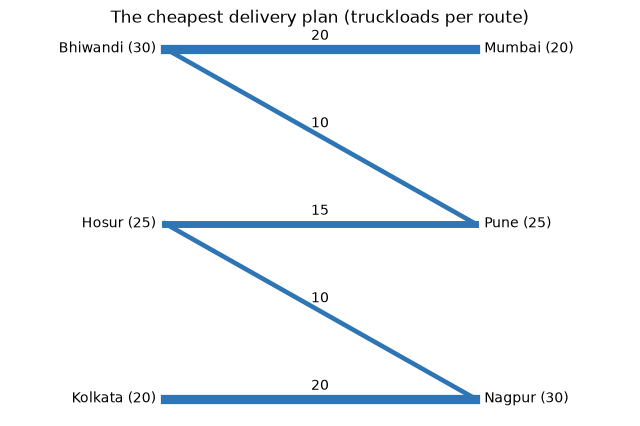

In [9]:
plt.figure(figsize=(8, 5))
w_y = {"Bhiwandi": 3, "Hosur": 2, "Kolkata": 1}
c_y = {"Mumbai": 3, "Pune": 2, "Nagpur": 1}

for (w, c), trucks in ship.items():
    if trucks.varValue > 0:
        plt.plot([0, 1], [w_y[w], c_y[c]], color="#2E75B6", linewidth=trucks.varValue / 3)
        plt.text(0.5, (w_y[w] + c_y[c]) / 2 + 0.05, str(int(trucks.varValue)), ha="center")

for w, y in w_y.items():
    plt.text(-0.03, y, w + " (" + str(supply[w]) + ")", ha="right", va="center")
for c, y in c_y.items():
    plt.text(1.03, y, c + " (" + str(demand[c]) + ")", ha="left", va="center")

plt.xlim(-0.5, 1.5)
plt.axis("off")
plt.title("The cheapest delivery plan (truckloads per route)")
plt.show()

## Step 8 — your turn: Nagpur needs more

A festival pushes Nagpur's demand from 30 to 35 truckloads. The warehouses still hold
75 in total. Predict the verdict before you run the cell.

In [10]:
plan.constraints["demand_Nagpur"].changeRHS(35)     # the rule is now "at least 35"

plan.solve(pulp.PULP_CBC_CMD(msg=0))
print("status:", pulp.LpStatus[plan.status])

status: Infeasible


`Infeasible`: the cities now need 80 truckloads and the warehouses hold 75. The fix is a
business decision: rent more stock, or tell Nagpur it gets 30. Put the rule back before
the next cell.

In [11]:
plan.constraints["demand_Nagpur"].changeRHS(30)
plan.solve(pulp.PULP_CBC_CMD(msg=0))
print("status:", pulp.LpStatus[plan.status], "  bill: Rs", pulp.value(plan.objective), "thousand")

status: Optimal   bill: Rs 405.0 thousand


### Stretch (optional) — what does one more truckload to each city cost?

Skip this if the notebook already felt like plenty. The shadow price of each demand rule
answers a planner's real question: if this city needed one more truckload, how much
would the cheapest bill rise? (With supply exactly equal to demand the answer also
depends on which warehouse gets the extra stock, so treat these as rough guides.)

In [12]:
for c in cities:
    rule = plan.constraints["demand_" + c]
    print(f"one more truckload to {c:6s}: about Rs {rule.pi:.0f} thousand")

one more truckload to Mumbai: about Rs 5 thousand
one more truckload to Pune  : about Rs 7 thousand
one more truckload to Nagpur: about Rs 8 thousand


## What you just did

You modelled a transportation problem: a variable per route, an objective summing cost
times truckloads, supply limits on the warehouses and demand minimums on the cities. CBC
found the cheapest plan, you checked every rule by hand, drew the network, and broke it
on purpose. Large retailers and couriers solve this same structure with thousands of
warehouses and pin codes. It is the same recipe you used for the thali.